# Optimal Time-Step

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.sparse.linalg import LinearOperator, cg
from mpl_toolkits.mplot3d import Axes3D


In [2]:
import numpy as np
import pandas as pd
import sys
import itertools

# Local imports
# Add the directory containing model_utils.py to the Python path
sys.path.append('../models')
from pi_npz import PhysicsInformedNN, DNN, forward_pinn
from traditional_npz import npz_nl, rk4, run_rk4_for_initial_conditions
sys.path.append('../utils')
from additional_files import calculate_rel_error, calculate_rmse, read_and_preprocess_data



In [3]:
total_days = 7 #23.5 / 24

intervals_per_day = 24 * 2 # Half Hour intervals (2 per hour)

# Calculate the total number of half-hour intervals
total_intervals = total_days * intervals_per_day

# Create an array from 0 to 7 days with half-hour intervals
times = np.arange(0, total_days + 1/intervals_per_day, 1/intervals_per_day)

if times[-1] > total_days:
    times = times[:-1]
    

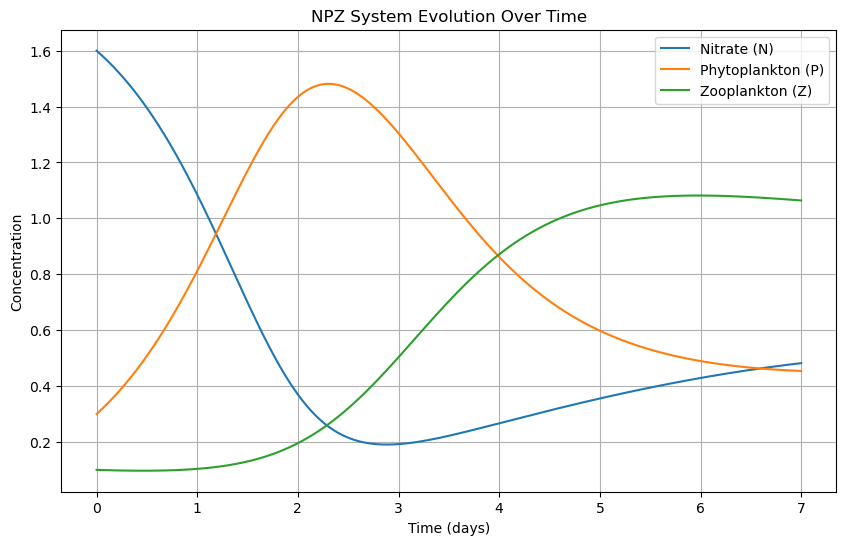

In [4]:
x0 = [1.6, 0.3, 0.1]
# x0 = np.array([0.70742625, 0.05118999, 0.05161794])
Vm = 2
ks = 1
m = 0.1
gamma = 0.3
Rm = 1.5
ivlev = 1
q = 0.2

tstart = 0 # Start time (day 0)
tend = total_days # End time (day 8)
minutes_per_step = 1 # Time step in minutes
minutes_per_hour = 60 # Constant time per hour
hours_per_day = 24 # Constant time per day
dt = minutes_per_step / (minutes_per_hour * hours_per_day)
t = np.arange(tstart, tend + dt, dt)  # Create the array of times

phi = (Vm, ks, m, Rm, ivlev, gamma, q)

xt = rk4(npz_nl, x0, t, None, 0, phi)


# 2D Plotting of the three components N, P, Z over time
plt.figure(figsize=(10, 6))
plt.plot(t, xt[:, 0], label='Nitrate (N)')
plt.plot(t, xt[:, 1], label='Phytoplankton (P)')
plt.plot(t, xt[:, 2], label='Zooplankton (Z)')
plt.xlabel('Time (days)')
plt.ylabel('Concentration')
plt.title('NPZ System Evolution Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
tstart_two_hrs = 0
tend_two_hrs = 120 / (60 * 24) # End time (day 8)
minutes_per_step_two_hrs = 1 # Time step in minutes
minutes_per_hour_two_hrs = 60 # Constant time per hour
hours_per_day_two_hrs = 24 # Constant time per day
dt_two_hrs = minutes_per_step_two_hrs / (minutes_per_hour_two_hrs * hours_per_day_two_hrs)
t_two_hrs = np.arange(tstart_two_hrs, tend_two_hrs + dt_two_hrs, dt_two_hrs)  # Create the array of times


In [6]:
x0_init = (1.6, 0.3, 0.1)

permutations = list(itertools.permutations(x0_init))
trajectories = [(0.641, 0.484, 0.874),
               (0.31476585, 1.34889816, 0.33633599)]

trajectories.extend(permutations)
# trajectories.extend(x0_init)
xt_list = []
for x0 in trajectories:
    xt_traj = rk4(npz_nl, x0, t, None, 0, phi)
    xt_list.append(xt_traj)
    

NameError: name 'itertools' is not defined

In [ ]:
# Placeholder for RMSE matrices
rmse_matrices = []

# Loop through each trajectory
for trajectory_idx, xt in enumerate(xt_list):
    num_steps = len(xt)
    trajectory_rmse_matrix = np.zeros((num_steps - len(t_two_hrs), len(t_two_hrs)))  # Rows: current step, Columns: next 200 steps

    # Calculate RMSE for each current time step compared to the next 200 steps
    for i in range(num_steps - len(t_two_hrs)):
        current_step = xt[i]  # Current time step (N, P, Z)

        for j in range(len(t_two_hrs)):
            future_step = xt[i + j + 1]  # Compare with future time step
            rmse = calculate_rmse(future_step, current_step)
            trajectory_rmse_matrix[i, j] = rmse

    # Store the RMSE matrix for this trajectory
    rmse_matrices.append(trajectory_rmse_matrix)
    

In [ ]:
# Initialize lists to store mean and std for each time step
mean_rmse_per_time_step = []
std_rmse_per_time_step = []

# Loop through RMSE matrices
for rmse_matrix in rmse_matrices:
    # Calculate mean and std along the rows (axis=0) for each time step
    mean_rmse = np.mean(rmse_matrix, axis=0)
    std_rmse = np.std(rmse_matrix, axis=0)

    # Append the results
    mean_rmse_per_time_step.append(mean_rmse)
    std_rmse_per_time_step.append(std_rmse)

# Convert to arrays for plotting
mean_rmse_per_time_step = np.array(mean_rmse_per_time_step)
std_rmse_per_time_step = np.array(std_rmse_per_time_step)

# Average across all RMSE matrices for final mean and std
final_mean_rmse = np.mean(mean_rmse_per_time_step, axis=0)
final_std_rmse = np.mean(std_rmse_per_time_step, axis=0)


In [ ]:
# Plotting
time_steps = np.arange(1, 122)  # Assuming 121 time steps forward

plt.figure(figsize=(12, 6))
plt.errorbar(t[:121] * 1440, final_mean_rmse, yerr=final_std_rmse, fmt='-o', capsize=3, label='Mean RMSE ± Std Dev')
plt.xlabel('Time (Minutes)')
plt.ylabel('RMSE')
plt.title('Mean and Standard Deviation of RMSE Over Time')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
threshold = 1e-3
minutes_per_step = 1  # You are now using 1 minute per step

acceptable_steps = np.where(final_mean_rmse < threshold)[0]
best_h = acceptable_steps[-1] + 1 if len(acceptable_steps) else 1
best_minutes = best_h * minutes_per_step

print(f"Best step: h = {best_h} → {best_minutes} minutes")



In [ ]:
for minutes in [5, 10, 15, 30, 60, 120]:
    h = minutes  # since 1 minute = 1 step
    print(f"RMSE at {minutes} min (h={h}): {final_mean_rmse[h - 1]:.6f}")


In [ ]:
rmse_15_min = final_mean_rmse[14]
print(f"RMSE at 15 minutes (h=15): {rmse_15_min:.6f}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define global font sizes
TITLE_FONT_SIZE = 16
AXIS_LABEL_FONT_SIZE = 14
TICK_LABEL_FONT_SIZE = 12
LEGEND_FONT_SIZE = 12

# Data (assuming 121 time steps forward)
time_steps = np.arange(1, 122)

plt.figure(figsize=(12, 6))

# Plot RMSE with error bars
plt.errorbar(t[:121] * 1440, final_mean_rmse, yerr=final_std_rmse, 
             fmt='-o', capsize=3, label='Mean RMSE ± Std Dev')

# Set labels and title with global font size variables
plt.xlabel('Time (Minutes)', fontsize=AXIS_LABEL_FONT_SIZE)
plt.ylabel('RMSE', fontsize=AXIS_LABEL_FONT_SIZE)
plt.title('Prediction Error Growth Over Time (Mean RMSE ± Std Dev)', fontsize=TITLE_FONT_SIZE)

# Set tick labels font size
plt.xticks(fontsize=TICK_LABEL_FONT_SIZE)
plt.yticks(fontsize=TICK_LABEL_FONT_SIZE)

# Adjust the x-axis ticks to count by 15
# plt.xticks(np.arange(0, np.max(t[:121] * 1440) + 1, 15 * 1440))  # Assuming each step is 1440 minutes
plt.xticks(np.arange(0, np.max(t[:121] * 1440) + 1, 15))  # 15-minute intervals
# Enable grid
plt.grid(True)

# Add legend with adjusted font size
plt.legend(fontsize=LEGEND_FONT_SIZE)

# Save figures
# plt.savefig("../figures/prediction_error_growth_over_time_figure.pdf")

# Show plot
plt.show()


In [ ]:
np.arange(0, np.max(t[:121] * 1440) + 1, 15 * 1440)

In [ ]:
t[:121] * 1440

In [ ]:
# Adjust the x-axis ticks to count by 15 minutes


# Or, if you meant every 15 hours instead of 15 minutes
# plt.xticks(np.arange(0, np.max(t[:121] * 1440) + 1, 15 * 60))  # 15-hour intervals


In [ ]:
np.arange(0, np.max(t[:121] * 1440) + 1, 15)